In [20]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

from dotenv import load_dotenv

load_dotenv()

DATA_DIR = Path(os.getenv("DATA_DIR"))
print(DATA_DIR)
print(DATA_DIR.is_dir())

TRAINING_PATH = DATA_DIR / "eta.csv"
print(TRAINING_PATH.is_file())

TEST_PATH = DATA_DIR / "ete.csv"
print(TEST_PATH.is_file())

/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data
True
True
True


In [21]:
import pandas as pd

hl_df_train = pd.read_csv(TRAINING_PATH, index_col=0)
hl_df_test = pd.read_csv(TEST_PATH, index_col=0)

df_full = pd.concat([hl_df_train, hl_df_test], axis=0)


In [22]:
hl_df_train.head()

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,dosprt,hltprhc
36122,3,3,6,5,1,0,21.453287,2,0
24898,6,3,2,2,4,0,25.181077,7,0
14759,4,1,3,2,2,0,23.529412,5,0
8874,5,4,4,2,3,0,30.487805,2,0
39895,4,4,2,2,2,0,26.769780,2,0


In [23]:
df_full

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,dosprt,hltprhc
36122,3,3,6,5,1,0,21.453287,2,0
24898,6,3,2,2,4,0,25.181077,7,0
14759,4,1,3,2,2,0,23.529412,5,0
8874,5,4,4,2,3,0,30.487805,2,0
39895,4,4,2,2,2,0,26.769780,2,0
...,...,...,...,...,...,...,...,...,...
41077,3,3,2,3,1,0,23.547881,5,0
41082,4,5,4,6,2,0,34.312524,0,0
41084,2,3,6,7,2,0,28.303850,5,0
41085,2,3,3,5,3,0,27.161612,2,0


In [24]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41104 entries, 36122 to 41101
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   etfruit   41104 non-null  int64  
 1   eatveg    41104 non-null  int64  
 2   cgtsmok   41104 non-null  int64  
 3   alcfreq   41104 non-null  int64  
 4   slprl     41104 non-null  int64  
 5   paccnois  41104 non-null  int64  
 6   bmi       41104 non-null  float64
 7   dosprt    41104 non-null  int64  
 8   hltprhc   41104 non-null  int64  
dtypes: float64(1), int64(8)
memory usage: 3.1 MB


## check unique values in features

In [25]:
continous_cols = ["bmi"]
int_cols = [col for col in list(df_full.columns)
            if col not in continous_cols]

In [26]:
uniques = {}

for col in int_cols:
    uniques[col] = sorted(df_full[col].unique())

for k, v in uniques.items():
    print(f"{k:8} : {v}")

etfruit  : [1, 2, 3, 4, 5, 6, 7]
eatveg   : [1, 2, 3, 4, 5, 6, 7]
cgtsmok  : [1, 2, 3, 4, 5, 6]
alcfreq  : [1, 2, 3, 4, 5, 6, 7]
slprl    : [1, 2, 3, 4]
paccnois : [0, 1]
dosprt   : [0, 1, 2, 3, 4, 5, 6, 7]
hltprhc  : [0, 1]


## check distributions

In [27]:
df_full.describe()

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,dosprt,hltprhc
count,41104.000000,41104.000000,41104.000000,41104.000000,41104.000000,41104.000000,41104.000000,41104.000000,41104.000000
mean,3.219078,3.149499,4.348190,4.621716,1.773550,0.045129,25.913786,3.164218,0.113566
std,1.309715,1.108940,1.830471,2.045234,0.830445,0.207590,4.147308,2.598171,0.317287
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,16.003658,0.000000,0.000000
25%,2.000000,2.000000,3.000000,3.000000,1.000000,0.000000,22.893074,0.000000,0.000000
50%,3.000000,3.000000,5.000000,5.000000,2.000000,0.000000,25.535446,3.000000,0.000000
75%,4.000000,4.000000,6.000000,7.000000,2.000000,0.000000,28.378215,5.000000,0.000000
max,7.000000,7.000000,6.000000,7.000000,4.000000,1.000000,40.000000,7.000000,1.000000


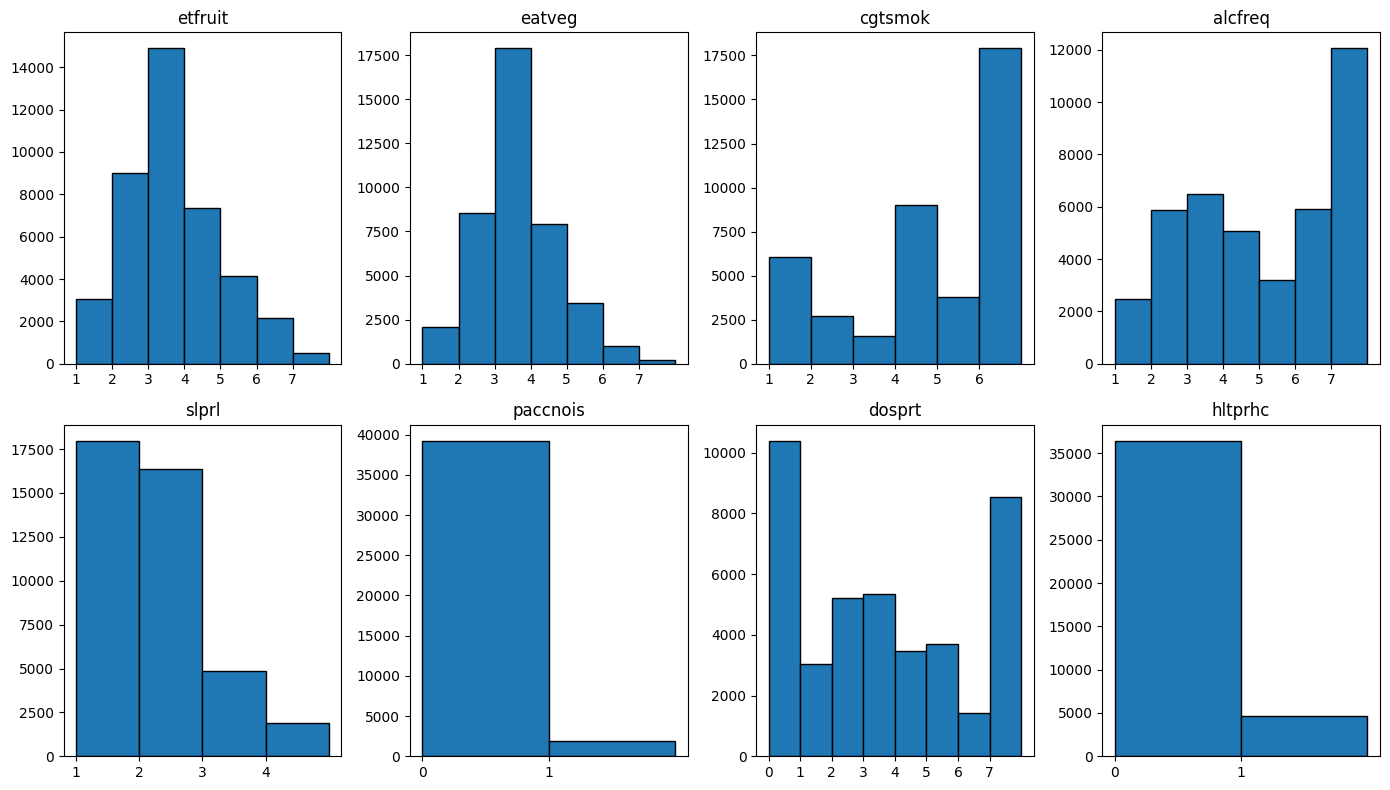

In [ ]:
import matplotlib.pyplot as plt

n = len(int_cols)
rows = (n + 3) // 4
cols = 4

fig, axes = plt.subplots(rows, cols, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, int_cols):
    data = df_full[col].dropna()
    col_min = int(data.min())
    col_max = int(data.max())

    ax.hist(data, bins=range(col_min, col_max + 2), edgecolor="black")
    ax.set_xticks(range(col_min, col_max + 1))
    ax.set_title(col)

for ax in axes[len(int_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


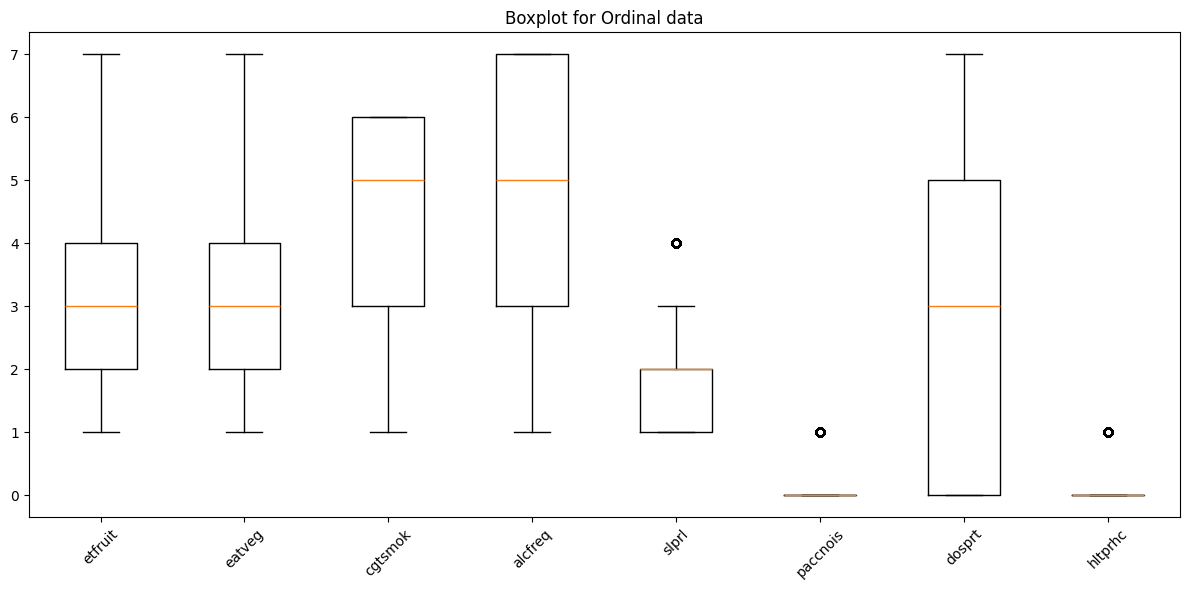

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.boxplot([df_full[col].dropna() for col in int_cols],
            tick_labels=int_cols)
plt.xticks(rotation=45)
plt.title("Boxplot for Ordinal data")
plt.tight_layout()
plt.show()

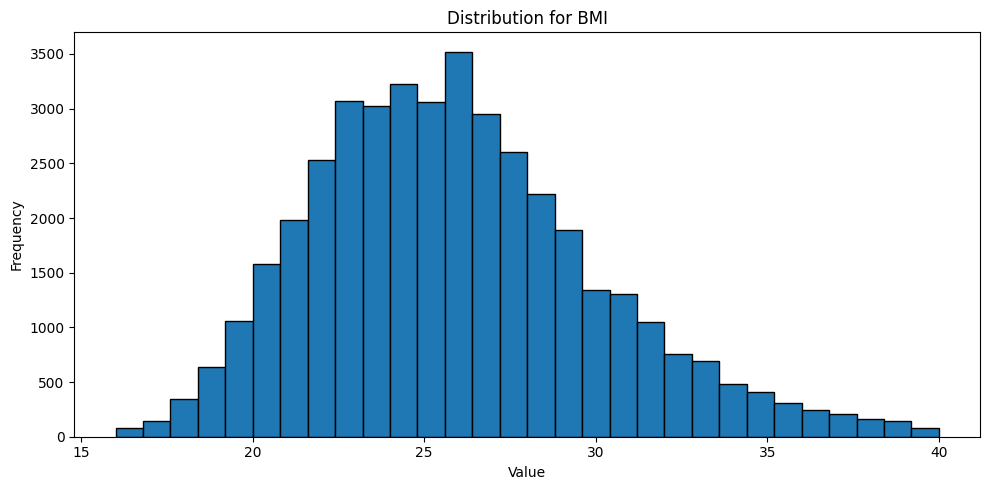

In [48]:
plt.figure(figsize=(10, 5))
plt.hist(df_full["bmi"], bins=30, edgecolor="black")
plt.title("Distribution for BMI")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


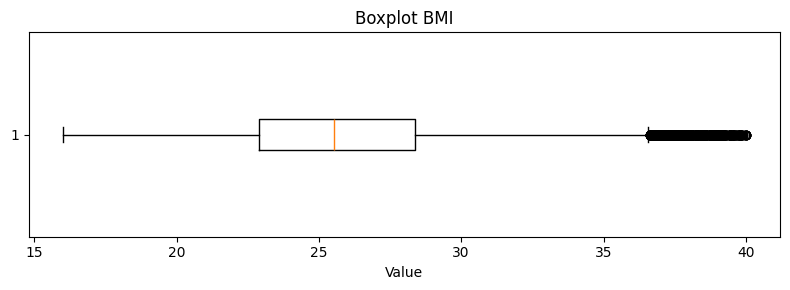

In [50]:
x = df_full["bmi"].dropna()

plt.figure(figsize=(8, 3))
plt.boxplot(x, vert=False)
plt.title("Boxplot BMI")
plt.xlabel("Value")
plt.tight_layout()
plt.show()


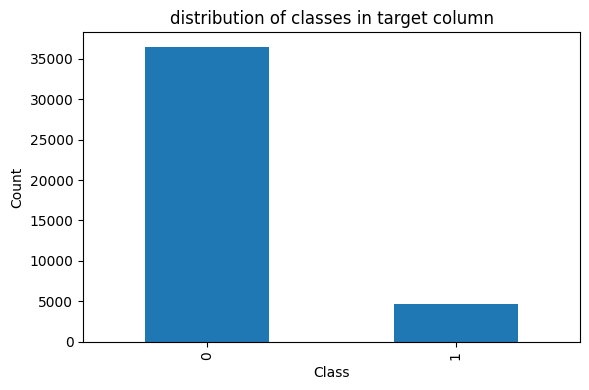

In [53]:
import matplotlib.pyplot as plt

target_col = "hltprhc"

plt.figure(figsize=(6, 4))
df_full[col].value_counts().plot(kind="bar")

plt.title(f"distribution of classes in target column")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


## Export

In [ ]:
df_full.to_csv(DATA_DIR / "full.csv")